### Import

In [19]:
import os
import pandas as pd
import seaborn as sns

### Loading Dataset

In [20]:
folder_path = "dataset"
dataframes = []
for file in os.listdir(folder_path):
    if file.startswith("openaq") and file.endswith(".csv"):
        full_path = os.path.join(folder_path, file)
        dfm = pd.read_csv(full_path)
        dataframes.append(dfm)
df = pd.concat(dataframes, ignore_index=True)

In [21]:
df.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,100,Badhoevedorp-Sloterweg,co,354.0,µg/m³,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
1,100,Badhoevedorp-Sloterweg,co,327.0,µg/m³,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
2,100,Badhoevedorp-Sloterweg,co,221.0,µg/m³,2025-01-01T05:00:00Z,2025-01-01T06:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
3,100,Badhoevedorp-Sloterweg,co,241.0,µg/m³,2025-01-01T06:00:00Z,2025-01-01T07:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA
4,100,Badhoevedorp-Sloterweg,co,251.0,µg/m³,2025-01-01T07:00:00Z,2025-01-01T08:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,NaN,NaN,NaN,Unknown Governmental Organization,EEA


In [22]:
print(df["country_iso"].isna().sum())

383965


In [23]:
len(df)

383965

### Data Cleaning

In [24]:
df=df.drop("country_iso", axis=1)

In [25]:
print(df["isMobile"].isna().sum())

383965


In [26]:
print(df["isMonitor"].isna().sum())

383965


In [27]:
df=df.drop("isMobile", axis=1)
df=df.drop("isMonitor", axis=1)

In [28]:
df.head()

,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,owner_name,provider
0,100,Badhoevedorp-Sloterweg,co,354.0,µg/m³,2025-01-01T01:00:00Z,2025-01-01T02:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
1,100,Badhoevedorp-Sloterweg,co,327.0,µg/m³,2025-01-01T02:00:00Z,2025-01-01T03:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
2,100,Badhoevedorp-Sloterweg,co,221.0,µg/m³,2025-01-01T05:00:00Z,2025-01-01T06:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
3,100,Badhoevedorp-Sloterweg,co,241.0,µg/m³,2025-01-01T06:00:00Z,2025-01-01T07:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA
4,100,Badhoevedorp-Sloterweg,co,251.0,µg/m³,2025-01-01T07:00:00Z,2025-01-01T08:00:00+01:00,Europe/Amsterdam,52.334003,4.774006,Unknown Governmental Organization,EEA


array([[<Axes: title={'center': 'location_id'}>,
        <Axes: title={'center': 'value'}>],
       [<Axes: title={'center': 'datetimeUtc'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>, <Axes: >]], dtype=object)

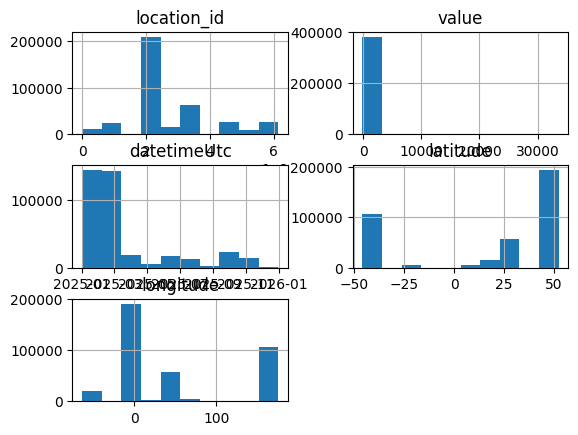

In [39]:
df.hist()

### Pivot the Data

In [30]:
df["datetimeUtc"] = pd.to_datetime(df["datetimeUtc"])
df_wide = df.pivot_table(index=["location_id", "datetimeUtc"], columns="parameter", values="value").reset_index()

In [31]:
df_wide.head(1000)

parameter,location_id,datetimeUtc,co,no,no2,o3,pm1,pm10,pm25,relativehumidity,so2,temperature,um003
0,100,2025-01-01 01:00:00+00:00,354.0,NaN,10.0,NaN,NaN,148.3,109.8,NaN,NaN,NaN,NaN
1,100,2025-01-01 02:00:00+00:00,327.0,NaN,11.8,NaN,NaN,66.6,60.9,NaN,NaN,NaN,NaN
2,100,2025-01-01 05:00:00+00:00,221.0,NaN,2.7,NaN,NaN,0.5,4.1,NaN,NaN,NaN,NaN
3,100,2025-01-01 06:00:00+00:00,241.0,NaN,4.3,NaN,NaN,4.4,7.7,NaN,NaN,NaN,NaN
4,100,2025-01-01 07:00:00+00:00,251.0,NaN,3.5,NaN,NaN,9.3,7.2,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,100,2025-03-21 16:00:00+00:00,313.0,NaN,13.7,NaN,NaN,58.0,11.3,NaN,NaN,NaN,NaN
996,100,2025-03-21 17:00:00+00:00,283.0,NaN,9.7,NaN,NaN,45.0,13.7,NaN,NaN,NaN,NaN
997,100,2025-03-21 18:00:00+00:00,305.0,NaN,14.3,NaN,NaN,50.5,13.0,NaN,NaN,NaN,NaN
998,100,2025-03-21 19:00:00+00:00,343.0,NaN,15.5,NaN,NaN,52.1,12.2,NaN,NaN,NaN,NaN
